## Exploring predictions

In [1]:
import sys
import gc
import random
import importlib as imp
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import experiment_settings
import build_model
import train_model
import build_data

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"tensorflow version = {tf.__version__}")  

tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on
# print(tf.config.list_physical_devices('GPU'))

python version = 3.10.10 | packaged by conda-forge | (main, Mar 24 2023, 20:12:31) [Clang 14.0.6 ]
numpy version = 1.23.2
tensorflow version = 2.10.0


In [3]:
# GET SETTINGS
EXP_NAME = "exp0"
settings = experiment_settings.get_settings(EXP_NAME)

SAVE_MODEL_DIRECTORY = "saved_models/"

# SET RANDOM SEEDS
np.random.seed(settings["rng_seed"])
random.seed(settings["rng_seed"])
tf.random.set_seed(settings["rng_seed"])



In [4]:
# LOAD THE DATA
imp.reload(build_data)

(tagyear_train, 
 taglat_train, 
 taglon_train,
 tagyear_val, 
 taglat_val, 
 taglon_val, 
 ) = build_data.make_sample_list(settings)

tfds_val = build_data.build_tf_dataset(settings, tagyear_val, taglat_val, taglon_val, settings["batch_size"])
tfds_val = tfds_val.prefetch(tf.data.AUTOTUNE)

batch_shape = np.shape(next(tfds_val.as_numpy_iterator())[0])
print(f"{batch_shape = }")

output region shape = (90, 90)
ntrain = 6400, nval = 800
batch_shape = (32, 114, 114, 6)


In [5]:
imp.reload(build_model)
imp.reload(train_model)

tf.keras.backend.clear_session()
model = build_model.build_model(settings, input_shape=batch_shape[1:])

checkpoint_dir = SAVE_MODEL_DIRECTORY + settings["exp_name"] + '/'
model.load_weights(tf.train.latest_checkpoint(checkpoint_dir))

labels_val = np.asarray([labels[0].numpy() for _, labels in tfds_val.unbatch()])
predict_val = model.predict(tfds_val, verbose=1)[:,0]
__ = gc.collect()

25/25 [==============================] - 5s 178ms/step


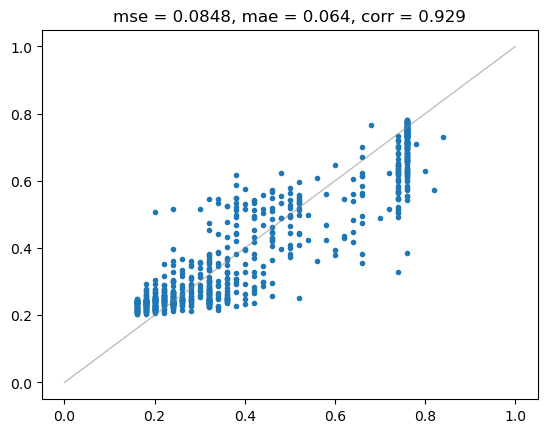

In [6]:
mse = np.sqrt(mean_squared_error(labels_val, predict_val)).round(4)
mae = mean_absolute_error(labels_val, predict_val).round(4)
corr = np.corrcoef(labels_val, predict_val)[0,1].round(4)

plt.figure()
plt.title(f'{mse = }, {mae = }, {corr = }')
plt.plot(labels_val, predict_val, '.')
plt.plot((0,1), (0,1), '-', linewidth=1, color="gray", alpha=.5)
plt.show()